<a href="https://colab.research.google.com/github/prishabobde/CS_181_ComputerVision/blob/main/CS181_HW6_B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Drawing Epipolar Lines
- origin = top left
- Goal: visualize epipolar lines in the right image (image2) corresponding to points in image1 (left image): (150, 305) and (312, 237)

In [ ]:
import numpy as np
import cv2
from google.colab import files
import matplotlib.pyplot as plt


In [ ]:
uploaded = files.upload()

for name, data in uploaded.items(): #saving to disk
    with open(name, "wb") as f:
        f.write(data)

image1 = cv2.imread("left.jpg")
image2 = cv2.imread("right.jpg")

Saving left.jpg to left (1).jpg
Saving right.jpg to right (1).jpg


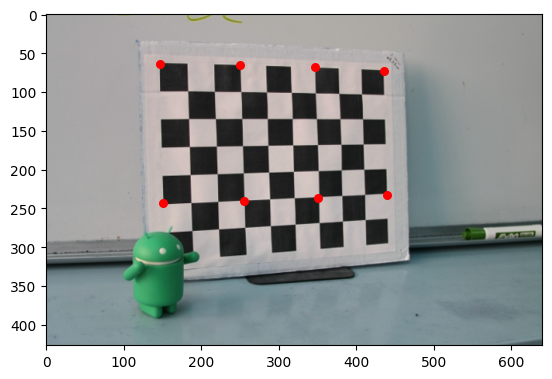

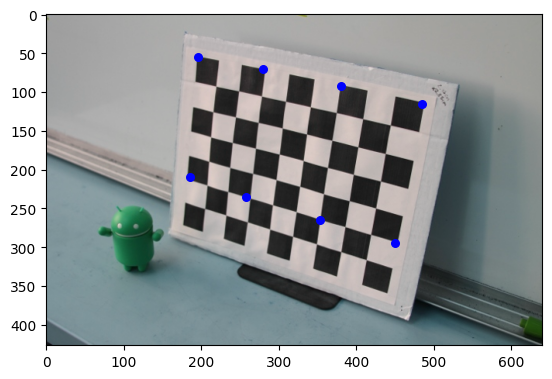

In [ ]:
#finding 8 corresponding points

#each row = [x,y]
pts1 = np.array([
    [147, 63],
    [150,243],
    [250,65],
    [255,240],
    [347,67],
    [350,237],
    [435,72],
    [440,232]

], dtype = float)

pts2 = np.array([
    [195,55],
    [185,210],
    [280,70],
    [257,235],
    [380,92],
    [353,265],
    [485,115],
    [450,295]
], dtype = float)



#displaying image
plt.imshow(image1)

for i, (x,y) in enumerate(pts1):
  plt.scatter(x, y, c="red", s=30)

plt.show()

plt.imshow(image2)

for i, (x,y) in enumerate(pts2):
  plt.scatter(x, y, c="blue", s=30)

plt.show()




In [ ]:
#two points of interest
target_pts = [(150,305), (321,237)]

In [ ]:
def normalized(pts):
  center = np.mean(pts, axis=0)
  #shift to orig
  pts_translated = pts - center

  #avg distance to orig = sqrt(2)
  distances = np.sqrt(np.sum(pts_translated**2, axis=1))
  mean_distances = np.mean(distances)

  s = np.sqrt(2) / mean_distances
  x_bar = center[0]
  y_bar = center[1]

  #forming similarity transforms
  T = np.array([
      [s, 0, -s*x_bar],
      [0, s, -s*y_bar],
      [0, 0, 1]
  ])

  #converting to homogenous
  homogenous_pts = np.hstack([pts, np.ones((pts.shape[0], 1))])
  pts_norm = (T @ homogenous_pts.T).T[:, :2]

  return pts_norm, T

In [ ]:
#fundamental matrix --> using 8 pt alg
def compute_F(pts1, pts2):
    pts1_n, T1 = normalized(pts1)
    pts2_n, T2 = normalized(pts2)

    A = []
    for (x,y),(xp,yp) in zip(pts1_n, pts2_n):
        A.append([xp*x, xp*y, xp, yp*x, yp*y, yp, x, y, 1])
    A = np.array(A)

    U, S, Vt = np.linalg.svd(A)
    F_norm = Vt[-1].reshape(3,3)

    # enforcing rank-2 --> setting smallest singular value F to 0
    U2, S2, Vt2 = np.linalg.svd(F_norm)
    S2[-1] = 0
    F_norm = U2 @ np.diag(S2) @ Vt2   #using result to calc epipolar lines

    # denormalize
    F = T2.T @ F_norm @ T1
    return F



In [ ]:
#epipolar lines in right image
def epiline(F, x, y):
  p = np.array([x,y,1])
  l = F @ p
  return l / np.sqrt(l[0]**2 + l[1]**2)




In [ ]:
# def drawEpipolarLine(x, y, right_image, F):
#   #corresponding epipolar line is l′ = F x
#   p = np.array([x,y,1.0])  #converting point to homogenous coords

#   #l' = Fp
#   l = F @ p
#   a,b,c = l   # l' = [a, b, c]  is ax + by + c = 0

#   #line intersections
#   x0, x1 = 0, w
#   y0 = -(a * x0 + c) / b
#   y1 = -(a * x1 + c) / b

#   # Plot
#   plt.imshow(right_image)
#   plt.plot([x0, x1], [y0, y1], 'r-', linewidth=2)  # epipolar line
#   plt.scatter([ ], [ ])  #
#   plt.axis('off')
#   plt.show()





In [ ]:
def drawEpipolarLine(x, y, right_image, F, ax=None, color='r'):
    p = np.array([x, y, 1.0])
    l = F @ p
    a, b, c = l
    h, w = right_image.shape[:2]
    x0, x1 = 0, w
    y0 = -(a*x0 + c)/b
    y1 = -(a*x1 + c)/b
    if ax is None:
        plt.imshow(right_image, cmap='gray')
        plt.plot([x0, x1], [y0, y1], color=color, linewidth=2)
        plt.axis('off')
        #plt.show()
    else:
        ax.plot([x0, x1], [y0, y1], color=color, linewidth=2)


Fundamental Matrix:
 [[-2.96529284e-06  7.64733760e-06  1.49135763e-03]
 [ 1.51764309e-05 -7.75951363e-05  4.64808551e-03]
 [-2.58139531e-03  1.31906101e-02 -7.88134854e-01]]


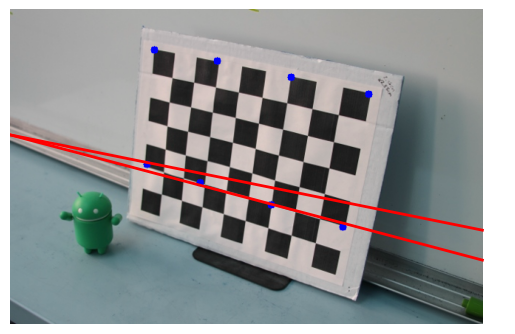

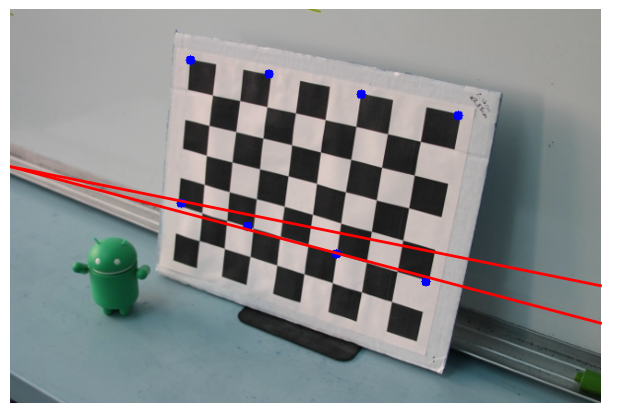

In [ ]:
F = compute_F(pts1, pts2)
print("Fundamental Matrix:\n",F)


left = image1.copy()
right=image2.copy()

# Draw points on left image
for (x, y) in pts1:
    cv2.circle(left, (int(x), int(y)), 5, (255,0,0), -1)

# Draw points on right image
for (x, y) in pts2:
    cv2.circle(right, (int(x), int(y)), 5, (0,0,255), -1)

# Epipolar lines for target
for (x, y) in target_pts:
    # mark the query point on left image
    cv2.circle(left, (int(x), int(y)), 8, (0,255,255), -1)

    # draw epipolar line on right image
    # drawEpipolarLine plots directly using matplotlib
    drawEpipolarLine(x, y, right, F)

fig, ax = plt.subplots(figsize=(8,6))
ax.imshow(right, cmap='gray')
for (x,y) in target_pts:
    drawEpipolarLine(x, y, right, F, ax=ax)
plt.axis('off')
plt.show()



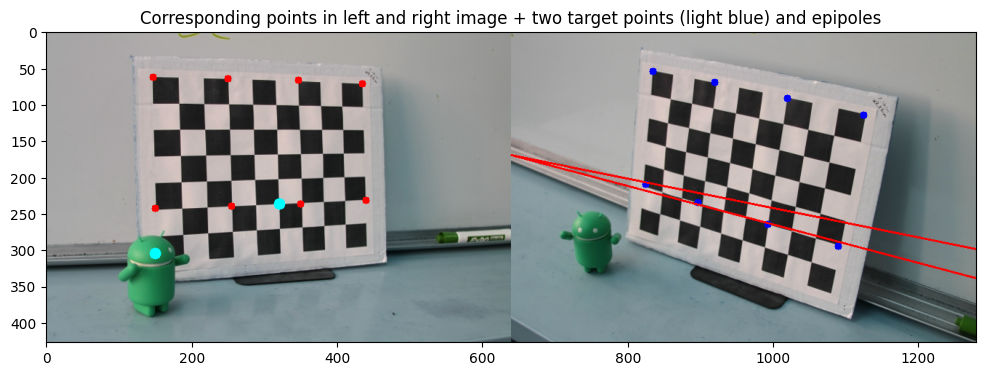

In [ ]:
#everything together --> both images
# Fixed points in left image
target_pts = [(150, 305), (321, 237)]

# Make copies
left_img = image1.copy()
right_img = image2.copy()

# Draw correspondences (optional)
for (x,y) in pts1:
    cv2.circle(left_img, (int(x), int(y)), 5, (255,0,0), -1)
for (x,y) in pts2:
    cv2.circle(right_img, (int(x), int(y)), 5, (0,0,255), -1)

# Draw the two fixed points on the left image
for (x,y) in target_pts:
    cv2.circle(left_img, (int(x), int(y)), 8, (0,255,255), -1)

#part 2: horizontal concatenation
h = max(left_img.shape[0], right_img.shape[0])
w = left_img.shape[1] + right_img.shape[1]
composite = np.zeros((h, w, 3), dtype=np.uint8)
composite[:left_img.shape[0], :left_img.shape[1]] = left_img
composite[:right_img.shape[0], left_img.shape[1]:] = right_img


#epipolar lines on the right image
for (x,y) in target_pts:
    #  epipolar line in right image coordinates
    l = F @ np.array([x, y, 1])
    a,b,c = l
    x0, x1 = 0, right_img.shape[1]    # intersect with x=0 and x=right_img width
    y0 = -(a*x0 + c)/b
    y1 = -(a*x1 + c)/b
    # shifting x-coords to composite image
    x0c, x1c = x0 + left_img.shape[1], x1 + left_img.shape[1]
    cv2.line(composite, (int(x0c), int(y0)), (int(x1c), int(y1)), (255,0,0), 2)   #line on composite

plt.figure(figsize=(12,6))
plt.imshow(composite)
plt.title("Corresponding points in left and right image + two target points (light blue) and epipoles")
plt.show()

#where the lines meet --> where the image was taken (left)
